In [1]:
# Load Dataset

import pandas as pd
import numpy as np

df = pd.read_csv("telecom_customer_churn_feature_engineering.csv")

In [2]:
# See the Problem

df[["monthly_income", "monthly_bill"]].describe()

,monthly_income,monthly_bill
count,1200.000000,1200.000000
mean,31155.975833,5939.150833
std,19351.937726,4046.473963
min,4984.000000,710.000000
25%,17795.000000,3291.750000
50%,26628.000000,4871.000000
75%,39886.250000,7485.500000
max,209790.000000,36361.000000


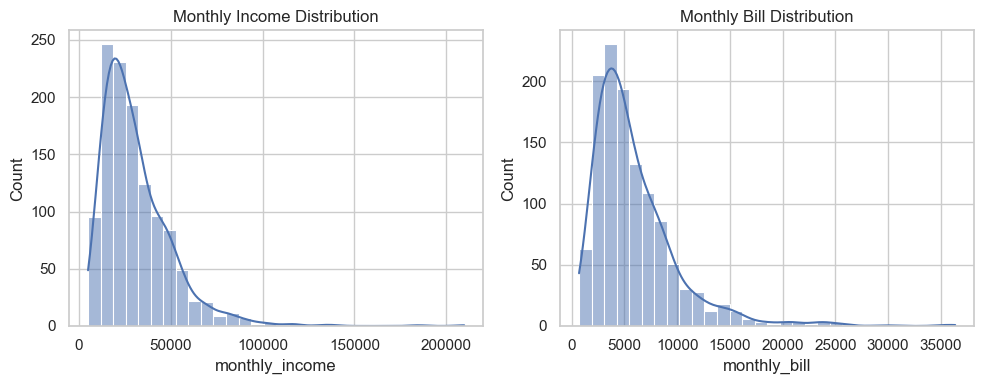

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)

sns.histplot(
    df["monthly_income"],
    kde=True,
    bins=30
)

plt.title("Monthly Income Distribution")

plt.subplot(1, 2, 2)
sns.histplot(
    df["monthly_bill"],
    kde=True,
    bins=30
)

plt.title("Monthly Bill Distribution")

plt.tight_layout()

plt.show()

In [5]:
# Safe Log Transformation

import numpy as np

df["income_log"] = np.log1p(df["monthly_income"])

df[["monthly_income", "income_log"]].head()

,monthly_income,income_log
0,57643.0,10.962041
1,18207.0,9.809616
2,13075.0,9.478534
3,38890.0,10.568518
4,17475.0,9.768584


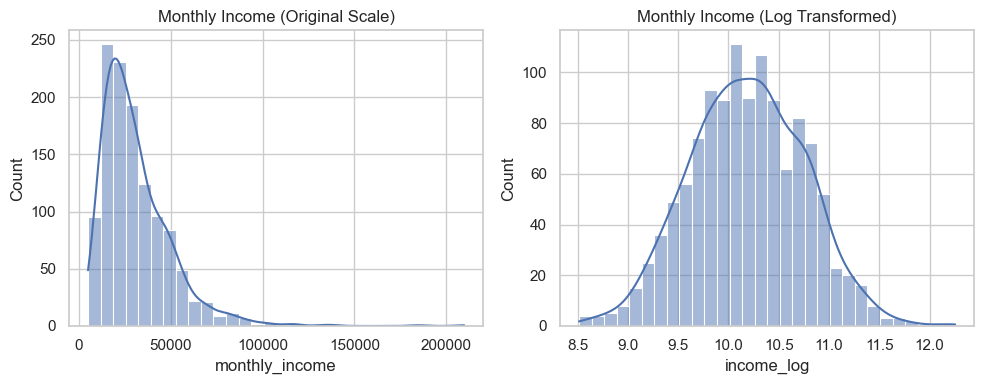

In [6]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)

sns.histplot(
    df["monthly_income"],
    kde=True,
    bins=30
)

plt.title("Monthly Income (Original Scale)")

plt.subplot(1, 2, 2)

sns.histplot(
    df["income_log"],
    kde=True,
    bins=30
)

plt.title("Monthly Income (Log Transformed)")

plt.tight_layout()

plt.show()

In [7]:
# Before vs After

df[["monthly_income", "income_log"]].describe()

,monthly_income,income_log
count,1200.000000,1200.000000
mean,31155.975833,10.185955
std,19351.937726,0.566190
min,4984.000000,8.514189
25%,17795.000000,9.786729
50%,26628.000000,10.189755
75%,39886.250000,10.593811
max,209790.000000,12.253867


In [8]:
# Clipping

upper_limit = df["monthly_bill"].quantile(0.99)

df["bill_clipped"] = df["monthly_bill"].clip(
    upper=upper_limit
)

df.loc[
    [
        df["monthly_bill"].idxmax(),
        df["monthly_bill"].sort_values().index[len(df)//2]
    ],
    ["monthly_bill", "bill_clipped"]
]

,monthly_bill,bill_clipped
968,36361.0,21696.4
47,4873.0,4873.0


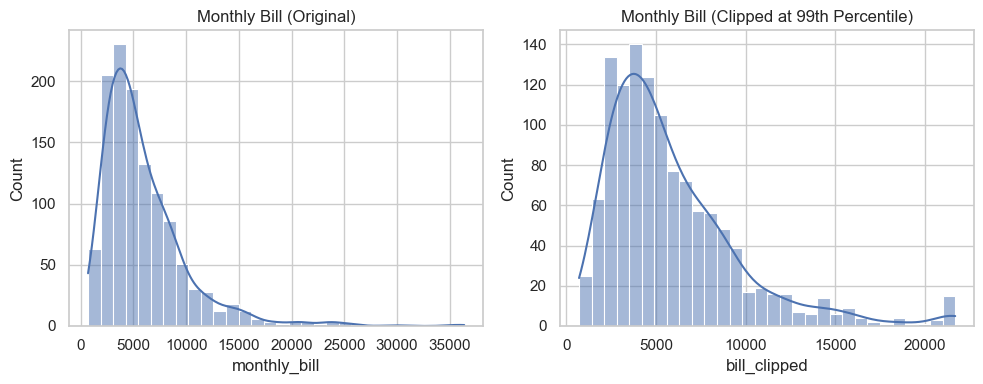

In [10]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)

sns.histplot(
    df["monthly_bill"],
    kde=True,
    bins=30
)

plt.title("Monthly Bill (Original)")

plt.subplot(1, 2, 2)

sns.histplot(
    df["bill_clipped"],
    kde=True,
    bins=30
)

plt.title("Monthly Bill (Clipped at 99th Percentile)")

plt.tight_layout()

plt.show()

In [11]:
from scipy.stats.mstats import winsorize

# Winsorize: cap only the top 1%

df["bill_winsor"] = winsorize(
    df["monthly_bill"],
    limits=[0.01, 0.01]   # [lower_cap, upper_cap]
)

# Check effect on extreme values

df.loc[
    [
        df["monthly_bill"].idxmin(),
        df["monthly_bill"].idxmax()
    ],
    ["bill_winsor"]
]

,bill_winsor
893,1140.0
968,21682.0


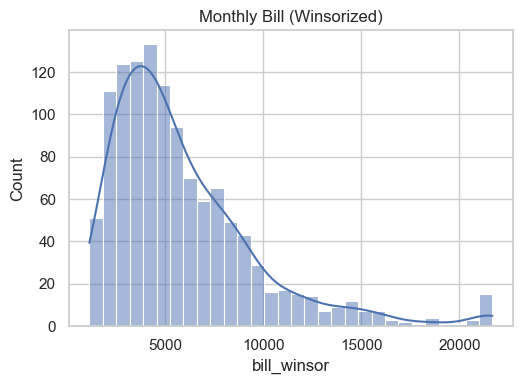

In [12]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 2)

sns.histplot(
    df["bill_winsor"],
    kde=True,
    bins=30
)

plt.title("Monthly Bill (Winsorized)")

plt.tight_layout()

plt.show()